<p class="mlx-kicker">Part IV &middot; Beyond the block &middot; Chapter 13</p>

# 13. Post-training: from instruction tuning to RL on verifiable rewards

<dl class="mlx-meta"><div><dt>Level</dt><dd>Advanced</dd></div><div><dt>Reading</dt><dd>about 30 min</dd></div><div><dt>Hands-on</dt><dd>about 6 min on a laptop CPU</dd></div><div><dt>You should know</dt><dd>Chapter 1, chapter 8 (cross-entropy), what a probability distribution and a gradient are</dd></div></dl>

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/daiyip/transformer-explained/blob/main/chapters/13-post-training/index.ipynb)

![The three generations of post-training. Each column highlights the one part that is new: written answers to imitate, comparisons between two answers, and a checker that scores sampled answers.](figures/posttrain-lineage.svg)

## What changed, and why it works

A pretrained model is a text continuer. Ask it a question and it may answer, or it may write three more questions, because both are plausible continuations of a web page. **Post-training** is the comparatively small amount of training after pretraining that turns this continuer into an assistant. None of the three generations in Figure 13.1 changes the network. Each changes only the training signal: what the model is shown, and what it is rewarded for. This chapter asks one question throughout: *what does that training actually change in the model?*

<div class="mlx-why">
<section class="mlx-why__card mlx-why__card--1"><p class="mlx-why__n">1 &middot; Instruction tuning</p><h3>Imitate written answers</h3><p><b>What changed.</b> The pretrained model is fine-tuned on pairs of an instruction and a good answer written by a person, with the usual next-token cross-entropy applied to the answer only. This is supervised fine-tuning (SFT).</p><p><b>Why it works.</b> Pretraining already put the knowledge and the styles into the model, so imitation only has to make one format much more likely than the others, which takes a small amount of data. Training on many different instructions pushes the model to learn the general rule (do what the instruction says) instead of a table of memorized replies, so it also follows instructions it never saw.</p><p class="mlx-why__run">Our runs: format followed 0% &rarr; 95% on trained words; on unseen words 0% after 16 instructions; after 414, 81% get the first letter right, but whole words are rare (0% to 16% across seeds)</p></section>
<section class="mlx-why__card mlx-why__card--2"><p class="mlx-why__n">2 &middot; Preference learning</p><h3>Learn from comparisons</h3><p><b>What changed.</b> People pick the better of two answers. RLHF fits a reward model to those choices and maximizes it with reinforcement learning, with a penalty for drifting away from the SFT model. DPO reaches the same target with one classification loss on the pairs, without a reward model.</p><p><b>Why it works.</b> Judging is easier than writing, so comparisons capture qualities nobody can demonstrate reliably. The drift penalty means the best solution is the SFT model's own distribution, reweighted toward preferred answers: the model is asked to change only as much as the reward pays for.</p><p class="mlx-why__run">Our runs: replies ending with a period 27% &rarr; 88% with best-of-8 at KL &le; 1.2 nats; DPO reached 81% only at 18 nats, and broke the format</p></section>
<section class="mlx-why__card mlx-why__card--3"><p class="mlx-why__n">3 &middot; RL on verifiable rewards</p><h3>Reward a checker's verdict</h3><p><b>What changed.</b> For tasks whose answers can be checked by a program, such as math and code, the model samples several answers per prompt, a checker rewards the correct ones, and each answer is pushed up or down by how much better it did than its group's average (GRPO).</p><p><b>Why it works.</b> A checker cannot be flattered, so the model can be optimized for a long time without learning to fool a learned reward model. The group average is a free baseline, so no value network is needed. Mostly, it moves probability onto correct answers the model could already sample.</p><p class="mlx-why__run">Our run: pass@1 25% &rarr; 47%, but pass@16 84% &rarr; 80%; distinct answers per 16 samples 7.3 &rarr; 4.3. pass@1 rose and distinct answers fell in all three seeds.</p></section>
</div>

Read left to right, the signal gets cheaper to collect but carries less information per example: a whole written answer, then one bit comparing two answers, then one bit per sample from a program. In exchange, the model has to do more of the search itself, by sampling. Our experiments point to one answer to the chapter's question: reward training mostly *reweights* answers the model can already produce. It is good at making them more likely and much weaker at creating new ones. **[likely]**

## Evolution path

| Year | Step | Level | What changed |
| --- | --- | --- | --- |
| 2017 | RL from human preferences (Christiano et al.) | minor | a reward model learned from comparisons, for games and simulated robots |
| 2020 | Learning to summarize (Stiennon et al.) | minor | RLHF with a KL penalty, applied to a language model |
| 2021-2022 | Instruction tuning: FLAN, T0, InstructGPT's SFT stage | **major** | fine-tune on demonstrations of many tasks phrased as instructions |
| 2022 | InstructGPT (Ouyang et al.) | **major** | SFT, then a reward model and PPO with a KL penalty; the recipe behind ChatGPT |
| 2022 | Constitutional AI (Bai et al.) | minor | feedback from an AI model replaces most human labels |
| 2023 | DPO (Rafailov et al.) | **major** | the RLHF objective as a classification loss on pairs: no reward model, no sampling |
| 2024 | GRPO (Shao et al.) | minor | the average reward of a group of samples replaces PPO's value network |
| 2024-2025 | RL on verifiable rewards: Tulu 3, OpenAI o1, DeepSeek-R1 | **major** | rewards from a checker; long chains of reasoning emerge from RL |

## The lineage post-mortem: what drove each replacement?

| Replacement | Pressure that drove it | What it bought |
| --- | --- | --- |
| pretrained model to SFT | the model continues text instead of answering | a usable assistant format from little data |
| SFT to RLHF | demonstrations cap quality at the writer's level, and some qualities are easier to judge than to write | optimizing what people prefer, not only what they wrote |
| RLHF (PPO) to DPO | PPO needs four networks in memory, online sampling and careful tuning | the same objective with a supervised-style loss |
| preference RL to verifiable rewards | learned reward models get exploited when optimized hard | a reward that cannot be fooled, so RL can run long enough to teach reasoning |

Read top to bottom, each step trades human effort for compute: first people write answers, then they only compare answers, then a program does the judging and the model generates its own training data. The direction is set by cost and by trust in the signal. Demonstrations are the most informative but the most expensive; a checker is nearly free and cannot be gamed by style, but exists only for tasks with checkable answers.

**Still open:** whether RL on verifiable rewards teaches new abilities or mainly sharpens existing ones (Yue et al., 2025, found that base models catch up when allowed many samples; longer RL runs may change that); why RL seems to forget less of the base model than SFT does; how to reward tasks with no checker, such as writing or open-ended advice; and whether offline methods like DPO can match online RL at scale.

## Run it yourself

The steps share this setup: TinyShakespeare and the chapter 1 model, pretrained in step 1. Each later step starts from the previous step's model, as in a real pipeline. Step 4 uses a separate tiny "calculator" model, because the Shakespeare alphabet has no digits. The whole notebook runs in about 6 minutes on one CPU thread.

In [1]:
# Setup: works from a checkout of the repo and on Google Colab.
import pathlib, subprocess, sys

try:
    import mlexp
except ImportError:
    root = pathlib.Path.cwd().resolve().parents[1]
    if (root / "mlexp").is_dir():
        sys.path.insert(0, str(root))
    else:  # Colab: install the shared helpers from GitHub
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", "git+https://github.com/daiyip/transformer-explained"], check=True)
    import mlexp

import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np

torch.manual_seed(0)
mlexp.setup_style()
device_note = "GPU available" if torch.cuda.is_available() else "running on CPU"
print(f"torch {torch.__version__}, {device_note}")

torch 2.14.1+cu130, running on CPU


In [2]:
import copy, math, random, re
from mlexp.transformer import TransformerLM

torch.set_num_threads(1)
tok, train_ids, val_ids = mlexp.load_char_corpus()
NEWLINE = tok.stoi["\n"]

### Step 1 (minor): a base model only continues text

Pretraining teaches a single skill: predict the next token of internet text (chapter 8). The model has no notion of a question, an instruction or an answer. A prompt is just the beginning of a document.

We pretrain a small chapter 1 model on TinyShakespeare for 600 steps. It is far from fluent, but it has learned spelling, line lengths and punctuation. Then we give it a prompt in the instruction format the rest of the chapter uses: a 4-letter word after `Q:`, and `A:` where the reply should start.

In [3]:
torch.manual_seed(0)
base = TransformerLM(tok.vocab_size, dim=96, n_layers=3, n_heads=4)
history = mlexp.train_lm(base, train_ids, val_ids, steps=600, block_size=64, eval_every=100)
print(f"base model: {mlexp.count_params(base):,} parameters, val loss {history['val'][-1]:.3f}")

step    0  train 4.418  val 4.433  (1s)


step  400  train 1.699  val 1.836  (46s)


step  600  train 1.606  val 1.767  (68s)
base model: 344,928 parameters, val loss 1.767


In [4]:
@torch.no_grad()
def sample(model, prompts, max_new=64, temperature=1.0, seed=0):
    """Continue each prompt until it writes a newline. All prompts must have the same length."""
    gen = torch.Generator().manual_seed(seed)
    model.eval()
    idx = torch.stack([tok.encode(p) for p in prompts])
    done = torch.zeros(len(prompts), dtype=torch.bool)
    for _ in range(max_new):
        logits, _ = model(idx)
        nxt = torch.multinomial(F.softmax(logits[:, -1] / temperature, -1), 1, generator=gen)
        nxt[done] = NEWLINE
        idx = torch.cat([idx, nxt], 1)
        done |= nxt[:, 0] == NEWLINE
        if done.all():
            break
    model.train()
    return [tok.decode(row).split("\n")[0] for row in idx[:, len(prompts[0]):].tolist()]


def prompt(word):
    return f"Q: {word}\nA: "


for reply in sample(base, [prompt("love")] * 4):
    print(repr(prompt("love") + reply))

"Q: love\nA: the nece! goMy fam? O my preceia, dispy 'it, and So prop,"
'Q: love\nA: your laged'
'Q: love\nA: but to my leck thy bised spicied:'
'Q: love\nA: risseenates of wrantess woo pritants unclous speaked impless mei'


The base model writes plausible-looking Shakespeare after `A:`, but nothing in it relates to the word `love`. It has no reason to: in its training data, `Q: love` was never followed by anything in particular.

### Step 2 (major): supervised fine-tuning on demonstrations

#### The idea

**Instruction tuning** fine-tunes the pretrained model on examples of instructions paired with good responses. FLAN (Wei et al., 2021) rephrased 62 existing datasets as instructions and found that the tuned model followed instructions for tasks it had never seen, and that this improved as more kinds of task were added. InstructGPT (Ouyang et al., 2022) used about 13,000 prompts with answers written by hired labelers as the first stage of its pipeline. The loss is plain cross-entropy, counted on the answer only, since the model should not be trained to write the user's prompt.

Our toy instruction is: `Q: love` asks for a line that **starts with the word "Love"**. We build the demonstrations from real Shakespeare: take each line that contains the word, and cut it so it starts there. To test whether SFT teaches the rule or memorizes examples, we make two training sets of equal size, one covering only 16 words and one covering 414 words, and we hold out 4 words (wife, poor, mine, bear) whose first letters match none of the 16.

<div class="mlx-box mlx-box--eq"><p class="mlx-box__label">Key equation: the SFT loss</p><div class="mlx-eq">$$\mathcal{L}_{\text{SFT}}(\theta) = -\sum_{t \in \text{answer}} \log \pi_\theta\big(y_t \,\big|\, x,\, y_{\lt t}\big)$$</div><p class="mlx-eq__where">\(x\) is the prompt and \(y\) the demonstrated answer. It is the pretraining loss of chapter 8, restricted to the answer tokens.</p></div>

#### Minimal implementation

In [5]:
SEEN = ["good", "lord", "king", "love", "time", "life", "true", "duke",
        "hand", "fair", "name", "fear", "eyes", "dead", "head", "soul"]
UNSEEN = ["wife", "poor", "mine", "bear"]  # never used for fine-tuning; initials unlike any seen word


def demonstrations(text):
    """For every 4-letter word, the corpus lines that contain it, cut to start at that word."""
    demos = {}
    for line in text.split("\n"):
        if 20 <= len(line) <= 60 and not line.endswith(":"):  # skip speaker names
            for w in sorted(set(re.findall(r"[a-z]+", line.lower()))):  # sorted: reproducible order
                if len(w) == 4:
                    rest = line[re.search(rf"\b{w}\b", line, re.I).start() + 4:]
                    if len(rest) >= 8:
                        demos.setdefault(w, []).append(w.capitalize() + rest)
    return demos


demos = demonstrations(tok.decode(train_ids))
narrow = [(prompt(w), r) for w in SEEN for r in demos[w]]
pool = [(prompt(w), r) for w, rs in demos.items() if w not in UNSEEN for r in rs]
broad = random.Random(1).sample(pool, len(narrow))  # same size, many more instructions
print(f"narrow set: {len(narrow)} demos over {len(SEEN)} words")
print(f"broad set:  {len(broad)} demos over {len(set(p for p, _ in broad))} words")
for p, r in narrow[:3]:
    print(repr(p + r))

narrow set: 2431 demos over 16 words
broad set:  2431 demos over 414 words
'Q: good\nA: Good citizens.'
'Q: good\nA: Good friends, mine honest neighbours,'
'Q: good\nA: Good friend;'


In [6]:
def response_logprobs(model, examples):
    """Log-probability of each response token given its prompt. Returns (B, T) log-probs and a 0/1 mask."""
    seqs = [tok.encode(p + r + "\n") for p, r in examples]
    x = torch.full((len(seqs), max(map(len, seqs))), NEWLINE)
    mask = torch.zeros(x.shape)
    for i, (s, (p, _)) in enumerate(zip(seqs, examples)):
        x[i, :len(s)] = s
        mask[i, len(p):len(s)] = 1  # score the response and its closing newline, not the prompt
    logits, _ = model(x[:, :-1])
    logp = torch.gather(F.log_softmax(logits, -1), 2, x[:, 1:, None]).squeeze(-1)
    return logp, mask[:, 1:]


def sft(model, data, steps=300, lr=1e-3, batch=32, seed=0):
    """Supervised fine-tuning: next-token cross-entropy on the response tokens only."""
    model, rng = copy.deepcopy(model), random.Random(seed)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=0.0)
    for _ in range(steps):
        logp, mask = response_logprobs(model, rng.sample(data, batch))
        loss = -(logp * mask).sum() / mask.sum()
        opt.zero_grad()
        loss.backward()
        opt.step()
    return model


torch.manual_seed(0)
sft_narrow = sft(base, narrow)
sft_broad = sft(base, broad)

The function `response_logprobs` is reused by every method in this chapter: SFT maximizes it, DPO compares it between two answers, and the RL step uses the same quantity for sampled answers. All prompts have the same length (every word has 4 letters), which keeps batched sampling simple.

#### Experiment: does SFT teach the rule or the examples?

We sample 8 replies per word from each model and check whether the reply starts with the requested word. For the held-out words we also check the softer target of getting the first letter right. Finally we measure how much each model's loss on ordinary Shakespeare text changed.

<div class="mlx-box mlx-box--predict"><p class="mlx-box__label">Predict first</p><p class="mlx-predict__q">Both SFT sets have 2,431 examples. Which model follows the format better on the 16 trained words, and which does better on the 4 words neither has seen?</p><details><summary>Show what happened</summary><p>The 16-word model is better on its own words (95% against 41%). On unseen words it scores 0%, and never even gets the first letter right. The 414-word model gets the first letter right on 81% of unseen replies (75% to 91% across three seeds) and copies the whole word in 16%, though only 3% and 0% in the other two seeds: it has started to learn "copy the word", while the 16-word model learned a lookup table.</p></details></div>

base            seen words   0% | unseen words   0% (first letter   0%) | Shakespeare val loss 1.782
                e.g. love -> 'counterly serves thy can dit: do, no, I that still with ow all K', wife -> "then,' no malt what cound I ward"


SFT, 16 words   seen words  95% | unseen words   0% (first letter   0%) | Shakespeare val loss 2.057
                e.g. love -> 'Love the your boy', wife -> "Life,' not all what comple"


SFT, 414 words  seen words  41% | unseen words  16% (first letter  81%) | Shakespeare val loss 2.040
                e.g. love -> 'Lord Exter,', wife -> "Wish,'Snay all what comple"


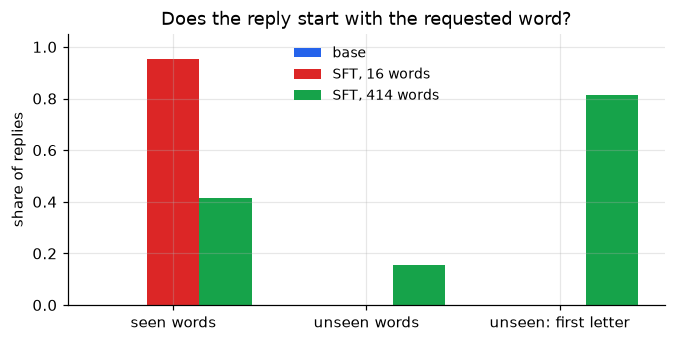

In [7]:
def adherence(model, words, n=8):
    """Share of sampled replies that start with the requested word, and with its first letter."""
    prompts = [prompt(w) for w in words for _ in range(n)]
    replies = sample(model, prompts)
    word = np.mean([r.startswith(p[3:7].capitalize()) for p, r in zip(prompts, replies)])
    letter = np.mean([r[:1] == p[3].upper() for p, r in zip(prompts, replies)])
    return word, letter, replies


@torch.no_grad()
def corpus_loss(model, batches=10):
    """Next-character loss on held-out Shakespeare: how much general text modelling survived."""
    gen = torch.Generator().manual_seed(1234)
    return np.mean([model(*mlexp.get_batch(val_ids, 32, 64, gen))[1].item() for _ in range(batches)])


results = {}
for name, m in [("base", base), ("SFT, 16 words", sft_narrow), ("SFT, 414 words", sft_broad)]:
    seen, _, ex_seen = adherence(m, SEEN)
    unseen, unseen_letter, ex_unseen = adherence(m, UNSEEN)
    results[name] = (seen, unseen, unseen_letter)
    print(f"{name:15s} seen words {seen:4.0%} | unseen words {unseen:4.0%} (first letter {unseen_letter:4.0%})"
          f" | Shakespeare val loss {corpus_loss(m):.3f}")
    print(f"{'':15s} e.g. love -> {ex_seen[24]!r}, wife -> {ex_unseen[0]!r}")

fig, ax = plt.subplots(figsize=(7, 3.2))
labels = ["seen words", "unseen words", "unseen: first letter"]
for i, (name, vals) in enumerate(results.items()):
    ax.bar(np.arange(3) + (i - 1) * 0.27, vals, 0.27, label=name)
ax.set(xticks=range(3), xticklabels=labels, ylabel="share of replies", ylim=(0, 1.05),
       title="Does the reply start with the requested word?")
ax.legend(frameon=False, fontsize=9);

#### Why it worked: a post-mortem

**A few hundred steps install the format.** The base model never starts a reply with the word; after 300 steps of SFT, 95% of replies do. The model already knew how to write such lines; SFT only had to make that continuation the likely one after `A:`. This is the "superficial alignment hypothesis" of LIMA (Zhou et al., 2023), who matched much larger instruction sets with 1,000 carefully chosen examples. **[likely]**

**Narrow data teaches a lookup table, varied data starts to teach the rule.** The 16-word model maps unseen words to trained ones: asked for `wife`, it answers `Life,' not all what comple`, and it never gets even the first letter of an unseen word right. The 414-word model, trained on the same number of examples, gets the first letter right 81% of the time (at least 75% in every seed we ran) and the whole word 16% of the time (0% to 16% across seeds). It pays for this on the trained words (41% against 95%), since it saw each of them far less often. Copying a whole word from the prompt is more than our small model fully learns in 300 steps, but the direction matches FLAN: more kinds of instructions, not more examples of the same ones, is what produces generalization to new instructions. **[established]** at scale, **[likely]** as the explanation of our toy.

**SFT moves the whole model.** Loss on ordinary Shakespeare rose from 1.782 to 2.057 for the 16-word model (2.040 for the 414-word one): fine-tuning on a narrow distribution of replies degrades what the model does elsewhere. Production SFT mixes in some pretraining data to limit this; Ouyang et al. (2022) did the same during RLHF to reduce this "alignment tax". **[established]**

### Step 3 (major): learning from preferences: a reward model and DPO

#### The idea

Some qualities are easier to judge than to demonstrate: helpfulness, tone, honesty. RLHF collects **comparisons**: the model writes two answers and a person picks the better one. Our stand-in for human taste is a simple rule the training methods are not told: *replies that end with a full stop are preferred*. About a quarter of the SFT model's replies end that way.

The classical recipe has two stages (Christiano et al., 2017; Stiennon et al., 2020; Ouyang et al., 2022):

1. **Reward model.** Fit a scalar score `\(r(x, y)\)` so that the preferred answer scores higher, using the Bradley-Terry model of comparisons.
2. **RL with a KL penalty.** Maximize the reward with PPO, minus a penalty on the KL divergence from the SFT model, which stops the policy drifting into text the reward model has never seen.

**DPO** (Rafailov et al., 2023) noticed that the KL-penalized objective has a closed-form optimum: the SFT model's distribution reweighted by `\(e^{r/\beta}\)`. Inverting that formula expresses the reward through the policy itself, `\(r = \beta \log \pi / \pi_{\text{ref}}\)` plus a constant, and substituting it into the Bradley-Terry loss gives a loss on the pairs that needs no reward model and no sampling.

<div class="mlx-box mlx-box--eq"><p class="mlx-box__label">Key equations: from comparisons to DPO</p><div class="mlx-eq">$$P(y_w \succ y_l) = \sigma\big(r(x,y_w) - r(x,y_l)\big), \qquad \max_\pi\; \mathbb{E}_{y\sim\pi}\big[r(x,y)\big] - \beta\, \mathrm{KL}\big(\pi \,\|\, \pi_{\text{ref}}\big)$$</div><div class="mlx-eq">$$\pi^*(y\mid x) \propto \pi_{\text{ref}}(y\mid x)\, e^{r(x,y)/\beta} \quad\Longrightarrow\quad \mathcal{L}_{\text{DPO}} = -\log \sigma\!\Big(\beta \log\frac{\pi(y_w\mid x)}{\pi_{\text{ref}}(y_w\mid x)} - \beta \log\frac{\pi(y_l\mid x)}{\pi_{\text{ref}}(y_l\mid x)}\Big)$$</div><p class="mlx-eq__where">\(y_w\) is the preferred (winning) answer and \(y_l\) the other one; \(\pi_{\text{ref}}\) is the SFT model and \(\beta\) sets how far the policy may move from it.</p></div>

PPO is too heavy for a CPU notebook. As the RL stand-in we use **best-of-n**: sample `\(n\)` replies from the SFT model and keep the one the reward model scores highest. It aims at the same target as KL-penalized RL, a reweighting of the SFT model's own samples, and its KL from the SFT model is at most `\(\log n - (n-1)/n\)` nats (Beirami et al., 2024). Stiennon et al. (2020) and Gao et al. (2022) use it as the reference point for RLHF.

#### Minimal implementation

The preference pairs are real lines that start with the requested word: one ending with a period, one not.

In [8]:
def ends_with_period(reply):
    """The hidden 'human' preference: replies that end with a full stop."""
    return float(reply.endswith("."))


rng = random.Random(0)
pairs = []  # (prompt, chosen, rejected): both are real lines starting with the word
for w in SEEN:
    good = [r for r in demos[w] if ends_with_period(r)]
    bad = [r for r in demos[w] if not ends_with_period(r)]
    pairs += [(prompt(w), rng.choice(good), rng.choice(bad)) for _ in range(40)]
rng.shuffle(pairs)
test_pairs, train_pairs = pairs[:128], pairs[128:]
print(f"{len(train_pairs)} training pairs, {len(test_pairs)} held out")
print("chosen:  ", repr(train_pairs[0][1]), "\nrejected:", repr(train_pairs[0][2]))

512 training pairs, 128 held out
chosen:   "Name, I'll ascend the regal throne." 
rejected: "Name, and the king's,"


The reward model is the SFT network with its vocabulary head replaced by a single number, read at the last token. Bradley-Terry training is logistic regression on the difference of two scores.

In [9]:
class RewardModel(nn.Module):
    """The SFT network with its next-token head replaced by one number read at the last token."""

    def __init__(self, lm):
        super().__init__()
        self.lm = copy.deepcopy(lm)
        self.score = nn.Linear(lm.head.in_features, 1)

    def forward(self, examples):
        seqs = [tok.encode(p + r + "\n") for p, r in examples]
        x = torch.full((len(seqs), max(map(len, seqs))), NEWLINE)
        for i, s in enumerate(seqs):
            x[i, :len(s)] = s
        h = self.lm.embed(x)
        for block in self.lm.blocks:
            h = block(h)
        last = torch.tensor([len(s) - 1 for s in seqs])
        return self.score(self.lm.norm(h)[torch.arange(len(seqs)), last]).squeeze(-1)


torch.manual_seed(0)
rm = RewardModel(sft_narrow)
opt = torch.optim.AdamW(rm.parameters(), lr=3e-4)
for step in range(60):
    batch = rng.sample(train_pairs, 32)
    r_chosen = rm([(p, c) for p, c, _ in batch])
    r_rejected = rm([(p, r) for p, _, r in batch])
    loss = -F.logsigmoid(r_chosen - r_rejected).mean()  # Bradley-Terry
    opt.zero_grad()
    loss.backward()
    opt.step()

with torch.no_grad():
    acc = (rm([(p, c) for p, c, _ in test_pairs]) > rm([(p, r) for p, _, r in test_pairs])).float().mean()
print(f"reward model: final training loss {loss.item():.4f}, held-out pair accuracy {acc:.0%}")

reward model: final training loss 0.0001, held-out pair accuracy 100%


To compare methods we need two numbers for each model: how much reward it earns, and how far it moved from the SFT model. The second is the KL divergence, which we estimate from the model's own samples as the average of `\(\log \pi(y) - \log \pi_{\text{ref}}(y)\)` over the whole reply. We also keep track of whether the step 2 format survives.

In [10]:
@torch.no_grad()
def evaluate(policy, ref, n=8):
    """Sample n replies per seen word; report the true reward, KL from the reference, and format."""
    prompts = [prompt(w) for w in SEEN for _ in range(n)]
    replies = sample(policy, prompts)
    examples = list(zip(prompts, replies))
    lp_pi, mask = response_logprobs(policy, examples)
    lp_ref, _ = response_logprobs(ref, examples)
    log_ratio = (lp_pi - lp_ref) * mask  # per token; its sum is a sample of KL(policy || ref)
    last = mask.sum(1).long() + mask.argmax(1) - 1  # position of the closing newline
    rows = torch.arange(len(examples))
    total = log_ratio.sum().item() or float("nan")  # zero when policy is the reference
    return dict(
        reward=np.mean([ends_with_period(r) for r in replies]),
        kl=log_ratio.sum(1).mean().item(),
        end_share=(log_ratio[rows, last] + log_ratio[rows, last - 1]).sum().item() / total,
        fmt=np.mean([r.startswith(p[3:7].capitalize()) for p, r in examples]),
        rm=rm(examples), true=torch.tensor([ends_with_period(r) for r in replies]), replies=replies,
    )


frontier = {}
ev = evaluate(sft_narrow, sft_narrow)
frontier["SFT"] = (0.0, ev["reward"], ev["fmt"])
print(f"SFT model: {ev['reward']:.0%} of replies end with a period, format {ev['fmt']:.0%}")

# Best-of-n: sample n replies, keep the one the reward model likes best.
for n in (2, 4, 8):
    scores, true = ev["rm"].view(len(SEEN), 8)[:, :n], ev["true"].view(len(SEEN), 8)[:, :n]
    pick = scores.argmax(1, keepdim=True)
    kl_bound = math.log(n) - (n - 1) / n  # Beirami et al. (2024): analytic upper bound on the KL
    fmt = np.mean([ev["replies"][i * 8 + j].startswith(SEEN[i].capitalize()) for i, j in enumerate(pick[:, 0].tolist())])
    frontier[f"best-of-{n}"] = (kl_bound, true.gather(1, pick).mean().item(), fmt)
    print(f"best-of-{n}: reward {frontier[f'best-of-{n}'][1]:.0%} at KL <= {kl_bound:.2f} nats, format {fmt:.0%}")

SFT model: 27% of replies end with a period, format 95%
best-of-2: reward 38% at KL <= 0.19 nats, format 88%
best-of-4: reward 62% at KL <= 0.64 nats, format 94%
best-of-8: reward 88% at KL <= 1.20 nats, format 94%


#### Experiment: reward bought per nat of KL

We train DPO on the 512 training pairs with three values of `\(\beta\)` (100 steps each) and compare them with best-of-2, 4 and 8.

<div class="mlx-box mlx-box--predict"><p class="mlx-box__label">Predict first</p><p class="mlx-predict__q">The preference concerns one character, the last one. Which buys more reward for the same KL: picking the best of 8 samples, or DPO? And does the format learned in step 2 survive?</p><details><summary>Show what happened</summary><p>Best-of-8 reaches 88% at a KL of at most 1.2 nats and keeps the format. DPO with \(\beta = 1\) reaches 62% at 1.35 nats. Lowering \(\beta\) buys a little more reward (81%) at a huge cost: 18 nats of KL, the format falls from 95% to 32%, and the replies turn to gibberish.</p></details></div>

In [11]:
def dpo(ref, pairs, beta, steps=100, lr=1e-4, batch=32, seed=0):
    """Direct Preference Optimization: a classification loss on pairs, no reward model, no sampling."""
    policy, rng = copy.deepcopy(ref), random.Random(seed)
    opt = torch.optim.AdamW(policy.parameters(), lr=lr, weight_decay=0.0)
    seq_logp = lambda m, ex: (lambda lp, mk: (lp * mk).sum(1))(*response_logprobs(m, ex))
    with torch.no_grad():  # the reference model never changes, so score it once
        ref_w = seq_logp(ref, [(p, c) for p, c, _ in pairs])
        ref_l = seq_logp(ref, [(p, r) for p, _, r in pairs])
    for _ in range(steps):
        ids = rng.sample(range(len(pairs)), batch)
        lw = seq_logp(policy, [(pairs[i][0], pairs[i][1]) for i in ids])
        ll = seq_logp(policy, [(pairs[i][0], pairs[i][2]) for i in ids])
        margin = beta * ((lw - ref_w[ids]) - (ll - ref_l[ids]))  # implicit reward of chosen minus rejected
        loss = -F.logsigmoid(margin).mean()
        opt.zero_grad()
        loss.backward()
        opt.step()
    return policy


for beta in (1.0, 0.3, 0.1):
    torch.manual_seed(0)
    ev = evaluate(dpo(sft_narrow, train_pairs, beta), sft_narrow)
    frontier[f"DPO beta={beta}"] = (ev["kl"], ev["reward"], ev["fmt"])
    print(f"DPO beta={beta}: reward {ev['reward']:.0%} at KL {ev['kl']:.2f} nats, format {ev['fmt']:.0%}, "
          f"share of log-ratio on the last two tokens {ev['end_share']:.0%}")
    print("    ", [r for r in ev["replies"][:24:8]])

DPO beta=1.0: reward 62% at KL 1.35 nats, format 92%, share of log-ratio on the last two tokens 9%
     ['Good chorse, Thengeds', 'Lord haus with he.', 'King prebased.']


DPO beta=0.3: reward 80% at KL 5.73 nats, format 73%, share of log-ratio on the last two tokens 5%
     ['Good chorse rece made', 'Lord haus stain is nate-sorrish nament.', 'King Henry. Qurrel.  I have shall pilgn, here fothousage shalf h']


DPO beta=0.1: reward 81% at KL 18.42 nats, format 32%, share of log-ratio on the last two tokens 4%
     ["De's chorse rece.", "Ld is hands the ends o'ert stoom them.", 'King Henbastings, Montness Warwill, I pail him.']


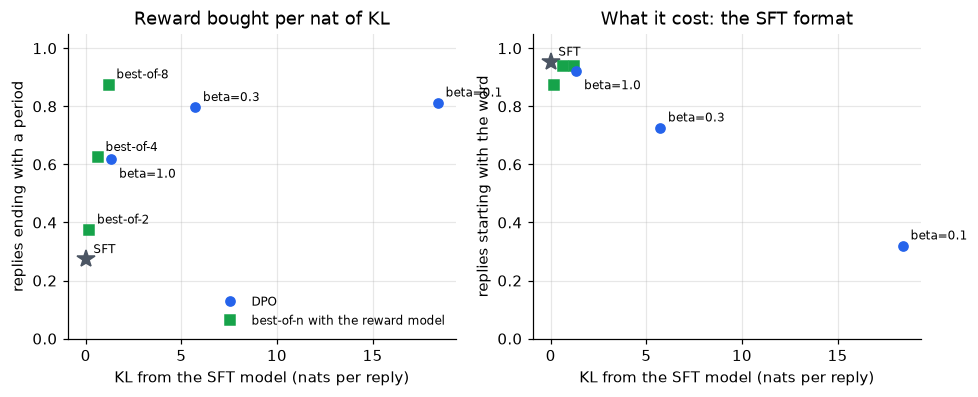

In [12]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3.6), sharex=True)
for name, (kl, reward, fmt) in frontier.items():
    style = dict(marker="s", color="#16a34a") if "best" in name else dict(marker="o", color="#2563eb")
    if name == "SFT":
        style = dict(marker="*", color="#4b5563", ms=12)
    for ax, y in ((ax1, reward), (ax2, fmt)):
        ax.plot(kl, y, linestyle="none", **style)
        if ax is ax2 and "best" in name:
            continue  # the best-of-n points sit on top of SFT in this panel
        below = name == "DPO beta=1.0"
        ax.annotate(name.replace("DPO ", ""), (kl, y), textcoords="offset points",
                    xytext=(5, -12 if below else 4), fontsize=8)
ax1.set(xlabel="KL from the SFT model (nats per reply)", ylabel="replies ending with a period",
        title="Reward bought per nat of KL", ylim=(0, 1.05))
ax2.set(xlabel="KL from the SFT model (nats per reply)", ylabel="replies starting with the word",
        title="What it cost: the SFT format", ylim=(0, 1.05))
ax1.plot([], [], "o", color="#2563eb", label="DPO")
ax1.plot([], [], "s", color="#16a34a", label="best-of-n with the reward model")
ax1.legend(frameon=False, fontsize=8, loc="lower right");

#### Why it worked: a post-mortem

**The reward model learned the rule perfectly**, with 100% held-out accuracy, because our preference is trivial and noise-free. Real preference data is not: InstructGPT's labelers agreed with each other only about 73% of the time, so real reward models are imperfect, and optimizing them hard finds their mistakes (Gao et al., 2022). **[established]**

**Best-of-n changes only what the preference needs.** Picking the reward model's favourite among 8 of the model's own replies raised the period rate from 27% to 88% at a KL of at most 1.2 nats, and the format stayed at 94%. Every reply it returns is one the SFT model wrote, so nothing else about the replies changes. This is also the distribution KL-penalized RL aims at, which is why RLHF with a reasonable `\(\beta\)` changes a model's behaviour much less than SFT does. **[established]** for the math, **[likely]** as a description of PPO in practice.

**Offline DPO paid for its reward with collateral damage.** At `\(\beta = 1\)` it reached 62% at 1.35 nats, no better than best-of-4. At small `\(\beta\)` it reached 81% but drifted 18 nats from the SFT model and lost most of the format. Two features of the loss explain this. It sees only the fixed pairs, never the model's own samples, so nothing checks what happens to replies outside the data. And it only rewards the *gap* between chosen and rejected, which can grow while the probability of both falls, pushing probability onto replies that appear nowhere in the data. Azar et al. (2023) and Xu et al. (2024) analyse this failure, and it is why practical DPO uses large `\(\beta\)`, few epochs, or fresh on-policy pairs. **[likely]**

**Where the change lands.** The preference is about the last character, yet only 4 to 9% of DPO's log-probability shift sits on the last character and the newline. That is about what those two tokens would get if the shift were spread evenly over a reply of about 28 characters: DPO changed the whole reply. So the answer to "what does reward training change?" depends on the method: reweighting the model's own samples changes little and precisely; an offline loss on fixed pairs can change a lot, in places the preference never mentioned. **[likely]**

**Caveat.** Single runs on a toy model and a toy preference. The direction of each result matches the literature; the exact numbers do not transfer.

### Step 4 (major): RL on verifiable rewards

#### The idea

For math and code, an answer can be checked by a program. Tulu 3 (Lambert et al., 2024) named this **RL with verifiable rewards** (RLVR); OpenAI's o1 (2024) and DeepSeek-R1 (2025) showed that training on such rewards with reinforcement learning makes models write long chains of reasoning, check their own work and score far higher on competition math. DeepSeek-R1 used **GRPO** (Shao et al., 2024): for each prompt, sample a group of `\(G\)` answers, score each with the checker, and use the score minus the group's mean, divided by the group's standard deviation, as the **advantage**. Answers that beat their siblings are made more likely, the others less likely. The group mean replaces the learned value network that PPO needs.

<div class="mlx-box mlx-box--eq"><p class="mlx-box__label">Key equation: the group-relative advantage</p><div class="mlx-eq">$$A_i = \frac{r_i - \operatorname{mean}(r_1,\dots,r_G)}{\operatorname{std}(r_1,\dots,r_G)}, \qquad \nabla_\theta J \approx \frac{1}{G}\sum_{i=1}^{G} A_i \sum_{t} \nabla_\theta \log \pi_\theta\big(y_{i,t} \mid x, y_{i,\lt t}\big)$$</div><p class="mlx-eq__where">\(r_i \in \{0, 1\}\) is the checker's verdict on sample \(i\). If every sample in a group gets the same reward, all advantages are zero and that prompt teaches nothing.</p></div>

Our task is adding two 2-digit numbers, written as text: `Q: 23+45` and the answer `68`. We first train a tiny model on worked examples until it is right about a quarter of the time when sampling, which mimics the R1 recipe of a short supervised "cold start" before RL. We take one gradient step per batch of samples, so PPO's clipping has nothing to clip, and we drop the KL penalty, as several recent recipes do.

#### Minimal implementation

In [13]:
math_tok = mlexp.CharTokenizer("0123456789+QA: \n")
P = 12  # every prompt "Q: 23+45\nA: " has 12 characters


def problem(rng):
    a, b = rng.randint(10, 99), rng.randint(10, 99)
    return f"Q: {a}+{b}\nA: ", str(a + b)


def sft_math(model, steps, rng, lr=3e-3):
    opt = torch.optim.AdamW(model.parameters(), lr=lr)
    for _ in range(steps):
        ex = [problem(rng) for _ in range(64)]
        seqs = torch.stack([math_tok.encode((p + a + "\n").ljust(16, "\n")) for p, a in ex])
        x, y = seqs[:, :-1], seqs[:, 1:].clone()
        y[:, :P - 1] = -100  # no loss on the prompt
        logits, _ = model(x)
        loss = F.cross_entropy(logits.flatten(0, 1), y.flatten(), ignore_index=-100)
        opt.zero_grad()
        loss.backward()
        opt.step()
    return model


torch.manual_seed(0)
data_rng = random.Random(0)
calc = sft_math(TransformerLM(math_tok.vocab_size, dim=64, n_layers=2, n_heads=4), 500, data_rng)
print(f"calculator model: {mlexp.count_params(calc):,} parameters, trained on 500 x 64 worked examples")

calculator model: 100,416 parameters, trained on 500 x 64 worked examples


In [14]:
@torch.no_grad()
def sample_answers(model, prompts, greedy=False, gen=None):
    idx = torch.stack([math_tok.encode(p) for p in prompts])
    for _ in range(4):  # up to three digits and a newline
        logits, _ = model(idx)
        last = logits[:, -1]
        nxt = last.argmax(-1, keepdim=True) if greedy else torch.multinomial(F.softmax(last, -1), 1, generator=gen)
        idx = torch.cat([idx, nxt], 1)
    return idx


def answer(row):
    text = math_tok.decode(row[P:])
    return text.split("\n")[0] if "\n" in text else None


test = [problem(random.Random(10_000 + i)) for i in range(256)]


def math_eval(model, k=16):
    """Greedy accuracy, pass@j for j <= k (from k samples per problem), distinct answers, entropy."""
    prompts = [p for p, _ in test]
    greedy = np.mean([answer(r) == a for r, (_, a) in zip(sample_answers(model, prompts, greedy=True).tolist(), test)])
    rows = sample_answers(model, [p for p in prompts for _ in range(k)], gen=torch.Generator().manual_seed(0)).tolist()
    correct = np.array([answer(r) == test[i // k][1] for i, r in enumerate(rows)]).reshape(-1, k).sum(1)
    pass_at = {j: np.mean([1 - math.comb(k - c, j) / math.comb(k, j) for c in correct]) for j in (1, 2, 4, 8, 16)}
    distinct = np.mean([len({answer(r) for r in rows[i * k:(i + 1) * k]}) for i in range(len(test))])
    with torch.no_grad():
        probs = F.softmax(model(torch.stack([math_tok.encode(p) for p in prompts]))[0][:, -1], -1)
    entropy = -(probs * probs.clamp_min(1e-12).log()).sum(-1).mean().item()
    return dict(greedy=greedy, pass_at=pass_at, distinct=distinct, entropy=entropy)


def show(name, e):
    print(f"{name:22s} greedy {e['greedy']:4.0%} | pass@1 {e['pass_at'][1]:4.0%} | pass@16 {e['pass_at'][16]:4.0%}"
          f" | distinct answers in 16 samples {e['distinct']:.1f} | first-digit entropy {e['entropy']:.2f} nats")


before = math_eval(calc)
show("before RL", before)

before RL              greedy  41% | pass@1  25% | pass@16  84% | distinct answers in 16 samples 7.3 | first-digit entropy 0.23 nats


`pass@k` is the chance that at least one of `\(k\)` samples is correct, estimated from 16 samples per problem with the unbiased formula of Chen et al. (2021). It separates two things: pass@1 measures how reliably the model answers, and pass@16 measures whether the right answer is in its repertoire at all.

#### Experiment: what does RL change?

We run 200 GRPO steps, each with 32 problems and 8 samples per problem. As a control, we instead give the same starting model 200 more steps of ordinary supervised training on correct worked examples.

<div class="mlx-box mlx-box--predict"><p class="mlx-box__label">Predict first</p><p class="mlx-predict__q">Before RL the model solves 25% of problems per sample, and 84% of problems are solved by at least one of 16 samples. After RL, which of the two numbers goes up more?</p><details><summary>Show what happened</summary><p>pass@1 almost doubles, to 47%. pass@16 does not rise at all: it slips to 80%. In the two other seeds we ran the starting model was much stronger, so pass@1 rose less (68% to 86%, 77% to 92%) and pass@16 stayed at 100%. The model gives fewer distinct answers (4.3 per 16 samples instead of 7.3). RL concentrated the model on answers it could already find.</p></details></div>

In [15]:
def grpo(model, steps=200, n_prompts=32, group=8, lr=3e-4, seed=0):
    """RL on a verifiable reward with group-relative advantages (GRPO without clipping or KL)."""
    model, rng = copy.deepcopy(model), random.Random(seed)
    gen = torch.Generator().manual_seed(seed)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=0.0)
    log = {"reward": [], "no_signal": []}
    for _ in range(steps):
        probs = [problem(rng) for _ in range(n_prompts)]
        seqs = sample_answers(model, [p for p, _ in probs for _ in range(group)], gen=gen)
        reward = torch.tensor([float(answer(r) == probs[i // group][1]) for i, r in enumerate(seqs.tolist())])
        reward = reward.view(n_prompts, group)
        adv = (reward - reward.mean(1, keepdim=True)) / (reward.std(1, keepdim=True) + 1e-4)  # relative to the group
        ans = seqs[:, P:]
        is_nl = (ans == math_tok.stoi["\n"]).long()
        mask = (is_nl.cumsum(1) - is_nl) == 0  # answer tokens up to and including the first newline
        logits, _ = model(seqs[:, :-1])
        logp = torch.gather(F.log_softmax(logits[:, P - 1:], -1), 2, ans[:, :, None]).squeeze(-1)
        loss = -(adv.flatten()[:, None] * logp * mask).sum() / mask.sum()  # policy gradient
        opt.zero_grad()
        loss.backward()
        opt.step()
        log["reward"].append(reward.mean().item())
        log["no_signal"].append((reward.std(1) == 0).float().mean().item())  # all right or all wrong
    return model, log


torch.manual_seed(0)
calc_rl, rl_log = grpo(calc)
after = math_eval(calc_rl)
show("after RL (GRPO)", after)

# Control: spend 200 more steps on supervised examples instead.
torch.manual_seed(0)
calc_sft = sft_math(copy.deepcopy(calc), 200, random.Random(1))
more_sft = math_eval(calc_sft)
show("after 200 more SFT", more_sft)

after RL (GRPO)        greedy  58% | pass@1  47% | pass@16  80% | distinct answers in 16 samples 4.3 | first-digit entropy 0.16 nats


after 200 more SFT     greedy  83% | pass@1  75% | pass@16  99% | distinct answers in 16 samples 2.1 | first-digit entropy 0.12 nats


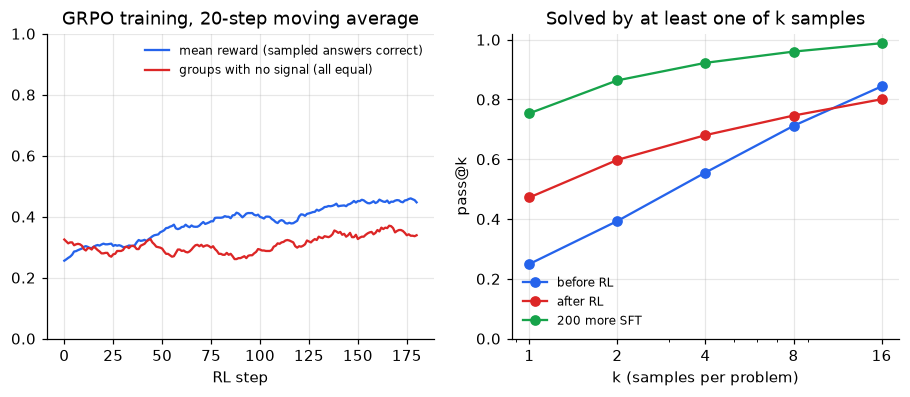

In [16]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3.6))
smooth = lambda v: np.convolve(v, np.ones(20) / 20, mode="valid")
ax1.plot(smooth(rl_log["reward"]), label="mean reward (sampled answers correct)")
ax1.plot(smooth(rl_log["no_signal"]), label="groups with no signal (all equal)")
ax1.set(xlabel="RL step", ylim=(0, 1), title="GRPO training, 20-step moving average")
ax1.legend(frameon=False, fontsize=8)
ks = [1, 2, 4, 8, 16]
for name, e in [("before RL", before), ("after RL", after), ("200 more SFT", more_sft)]:
    ax2.plot(ks, [e["pass_at"][k] for k in ks], marker="o", label=name)
ax2.set(xscale="log", xticks=ks, xticklabels=ks, xlabel="k (samples per problem)", ylabel="pass@k",
        ylim=(0, 1.02), title="Solved by at least one of k samples")
ax2.legend(frameon=False, fontsize=8);

#### Why it worked: a post-mortem

**RL sharpened the distribution.** pass@1 rose from 25% to 47% and greedy accuracy from 41% to 58%, while pass@16 stayed flat (84% to 80%), the number of distinct answers fell from 7.3 to 4.3 and the entropy of the first digit fell from 0.23 to 0.16 nats. The direction held in all three seeds we ran: pass@1 rose by 15 to 22 points, distinct answers fell, and pass@16 never rose (in two seeds it was already 100%). The policy gradient only raises the probability of answers that were sampled and rewarded, so it amplifies what the model can already do. Yue et al. (2025) found the same pattern in large reasoning models: RL-trained models win at pass@1, but the base model catches up and even overtakes them at large k. **[likely]** for frontier models; others report that much longer RL runs do expand what models can solve, and the question is open.

**Many groups carry no signal.** When all 8 samples for a problem are right, or all are wrong, every advantage is zero. The left plot shows this happens for about a third of the problems throughout training, so a good part of the sampling compute is wasted. This is why recipes such as DAPO filter out prompts that are too easy or too hard, and why RLVR depends on a starting model that sometimes succeeds. **[established]**

**When demonstrations are cheap, SFT is the safer choice.** With correct worked examples available, 200 more supervised steps reached 75% pass@1 and 99% pass@16, far better than RL in this run. The pass@1 comparison depends on the seed (77% against RL's 86% in one of our other seeds, 97% against 92% in the other), but SFT never lowered pass@16. Supervised data says exactly what the right answer is; a 0/1 reward only says whether a guess was right. RL earns its place where you can check an answer but cannot write the solution, such as long reasoning traces that nobody has written down, and that is where it transformed reasoning models. **[likely]**

**What reward training changed, in one sentence.** Across steps 3 and 4, the methods that sample from the model and reweight its outputs (best-of-n, GRPO) changed it little and in a targeted way: more probability on the outputs that score well, less variety. **[likely]**

## Across three seeds

The numbers on this page come from one run, seed 0. We reran the whole notebook twice more with every random seed shifted by 1 and by 2, which changes the initial weights, the batches and the evaluation samples (the `Seed runs` workflow in the repository does this for any chapter). A gap between two runs means something only when it is clearly larger than their spread.

| Run | This page (seed 0) | Mean ± sd, 3 seeds | Seeds 0 / 1 / 2 |
| --- | --- | --- | --- |
| SFT on 414 words: unseen word copied whole | 16% | 6% ± 9% | 16% / 3% / 0% |
| SFT on 414 words: right first letter | 81% | 82% ± 8% | 81% / 75% / 91% |
| Best-of-8 reward | 88% | 92% ± 3% | 88% / 94% / 94% |
| DPO β=1 reward | 62% | 68% ± 6% | 62% / 68% / 74% |
| DPO β=0.1 reward | 81% | 88% ± 6% | 81% / 92% / 92% |
| DPO β=0.1 format | 32% | 38% ± 12% | 32% / 30% / 52% |
| Before RL: pass@1 | 25% | 57% ± 28% | 25% / 68% / 77% |
| After GRPO: pass@1 | 47% | 75% ± 24% | 47% / 86% / 92% |
| Before RL: pass@16 | 84% | 95% ± 9% | 84% / 100% / 100% |
| After GRPO: pass@16 | 80% | 93% ± 12% | 80% / 100% / 100% |
| Before RL: distinct answers in 16 | 7.3 | 4.3 ± 2.6 | 7.3 / 3.2 / 2.4 |
| After GRPO: distinct answers in 16 | 4.3 | 2.8 ± 1.4 | 4.3 / 2.3 / 1.7 |
| After 200 more SFT steps: pass@1 | 75% | 83% ± 12% | 75% / 77% / 97% |
| After 200 more SFT steps: pass@16 | 99% | 100% ± 1% | 99% / 100% / 100% |

The format, best-of-N and DPO results held in every seed. Two claims did not: whole-word copying on unseen words appeared in one seed only (the first letter held), and SFT beat RL on pass@1 in two seeds of three. The RL pattern held: pass@1 rose and diversity fell every time, though the starting model varied a lot between seeds.

## Recap

<div class="mlx-box mlx-box--objectives"><p class="mlx-box__label">Recap</p><p>You should now be able to:</p><ol><li>Explain why a pretrained model does not follow instructions, and implement SFT with the loss on the answer only.</li><li>Train a Bradley-Terry reward model and derive the DPO loss from the KL-penalized RLHF objective.</li><li>Implement a GRPO-style update with group-relative advantages and a verifiable reward.</li><li>Measure what post-training changed, using KL from the reference model, pass@k and output diversity.</li></ol></div>

<div class="mlx-box mlx-box--check"><p class="mlx-box__label">Check your understanding</p><details><summary>Why is the SFT loss counted on the answer tokens only?</summary><p>The goal is to model good replies given a prompt, not to model the prompts users write. Training on the prompt would spend capacity on predicting user text and could teach the model to write like the user.</p></details><details><summary>In DPO, where did the reward model go?</summary><p>The KL-penalized objective has a closed-form optimum, the reference model reweighted by \(e^{r/\beta}\). Solving for \(r\) gives \(\beta \log \pi/\pi_{\text{ref}}\) plus a constant, so the policy itself defines the reward, and the constant cancels in the difference used by the Bradley-Terry loss.</p></details><details><summary>A GRPO group of 8 samples are all correct. How much does this prompt contribute to the update, and why?</summary><p>Nothing. Every reward equals the group mean, so every advantage is zero. Prompts that are always solved or never solved give no signal, which is why RLVR needs prompts of the right difficulty.</p></details><details><summary>After RL, pass@1 rises but pass@16 does not. What does that suggest RL did?</summary><p>It moved probability onto answers the model could already produce, making it more reliable without making it able to solve new problems. The set of problems it can solve with enough tries stayed the same.</p></details></div>

## Further reading

- Christiano et al., 2017, [Deep Reinforcement Learning from Human Preferences](https://arxiv.org/abs/1706.03741): reward models learned from comparisons.
- Wei et al., 2021, [Finetuned Language Models Are Zero-Shot Learners](https://arxiv.org/abs/2109.01652): FLAN and instruction tuning.
- Ouyang et al., 2022, [Training language models to follow instructions with human feedback](https://arxiv.org/abs/2203.02155): InstructGPT, SFT then RLHF.
- Gao, Schulman and Hilton, 2022, [Scaling Laws for Reward Model Overoptimization](https://arxiv.org/abs/2210.10760).
- Rafailov et al., 2023, [Direct Preference Optimization: Your Language Model is Secretly a Reward Model](https://arxiv.org/abs/2305.18290).
- Shao et al., 2024, [DeepSeekMath: Pushing the Limits of Mathematical Reasoning in Open Language Models](https://arxiv.org/abs/2402.03300): GRPO.
- DeepSeek-AI, 2025, [DeepSeek-R1: Incentivizing Reasoning Capability in LLMs via Reinforcement Learning](https://arxiv.org/abs/2501.12948).
- Yue et al., 2025, [Does Reinforcement Learning Really Incentivize Reasoning Capacity in LLMs Beyond the Base Model?](https://arxiv.org/abs/2504.13837)